# Projeto Fundamentos de Aprendizagem Automática

**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

## Problema
**Prever a nota final** com base em todas as variáveis comportamentais, exceto 


* student_id
* productivity_score  
* burnout_level 
* focus_index
    

## Variáveis-Alvo (Targets)

### Cenário de Regressão (y)

Prever **Exam Score** (nota de exame). 

## Stakeholders

- **Os próprios estudantes** :Beneficiariam ao compreender de forma clara como os seus hábitos de vida (como as horas de sono, tempo de ecrã e o balanço entre estudo e lazer) impactam diretamente o seu desempenho académico. Ter acesso a esta previsão permite-lhes ajustar comportamentos de forma proativa e atempada, evitando o insucesso escolar (chumbo) ou níveis extremos de exaustão (burnout).
    
- **A instituição de ensino / Escola** :Pode utilizar este modelo preditivo para identificar antecipadamente uma percentagem de alunos em risco de reprovação. Isto permite à gestão escolar uma melhor alocação de recursos pedagógicos, como a promoção de turmas de apoio extra ou a reavaliação da carga de trabalhos exigida.
    
- **Conselheiros / Tutores** :Passam a ter acesso a uma ferramenta de apoio à decisão baseada em dados reais para oferecer um acompanhamento muito mais personalizado. Em vez de conselhos genéricos, o tutor pode focar-se nas variáveis específicas que o modelo identificou como problemáticas para um determinado aluno (por exemplo, excesso de horas em videojogos ou falta de qualidade de sono).
    
- **Serviços de Apoio ao Estudante(Apoio Psicológico)** :Podem atuar de forma preventiva junto de alunos cujo perfil cruze um baixo rendimento académico com indicadores de má saúde mental (como altos níveis de ingestão de cafeína e privação de sono). O modelo serve como um sistema de alerta para oferecer suporte psicológico antes que o aluno atinja um ponto de rutura.


### Ler ficheiro obter feature Variables e Target Variables e tratar dados missing

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder


# ler ficherio de student_records com missing values
df_student_records = pd.read_csv('student_records_missing.csv')
df_colunas = df_student_records.columns


# imprimir percentagem missing values por coluna
missing_percent = df_student_records.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])


# Definir Variável y
y = df_student_records["exam_score"].copy()  # Variável y com a coluna "exam_score"




# Definir Variável X
df_student_records.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
X = df_student_records.copy()  # Variável X com as colunas restantes

# print(X.head())





# one split para separar os dados em treino e teste
X_learning, X_test, y_learning, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)




# Separar colunas numéricas e categóricas em X_learning para preencher os valores vazios
num_cols = X_learning.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_learning.select_dtypes(include=['object', 'string']).columns.tolist()



# Calcular a mediana para as colunas numéricas e a moda para as colunas categóricas em X_learning
medians = X_learning[num_cols].median()
modes = X_learning[cat_cols].mode().iloc[0]



# Preencher os valores vazios em X_learning com as medianas e modas calculadas
X_learning[num_cols] = X_learning[num_cols].fillna(medians)
X_learning[cat_cols] = X_learning[cat_cols].fillna(modes)

# Preencher os valores vazios em X_test com as mesmas medianas e modas calculadas a partir de X_learning
X_test[num_cols] = X_test[num_cols].fillna(medians)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)







print("\n Total atual de valores vazios :", X_learning.isnull().sum().sum() + X_test.isnull().sum().sum())
# print(X_learning.head())
# print(X_test.head())


#Utilizando(One-Hot Encoding) para transformar as colunas categóricas em variáveis dummy
X_learning = pd.get_dummies(X_learning, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
# print(X_learning.head())







--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64

 Total atual de valores vazios : 0


## 2. Feature Selection e Redução de Dimensionalidade

Aplicamos as 5 técnicas do TP05 adaptadas para regressão.
Para cada modelo, as 6 configurações são avaliadas com os mesmos hiperparâmetros base,
de modo a isolar o efeito da selecção de atributos.

Técnica A - Variance Threshold: 22 → 22 features
Técnica B - Correlation Filter: 22 → 22 features
  Removidas: []


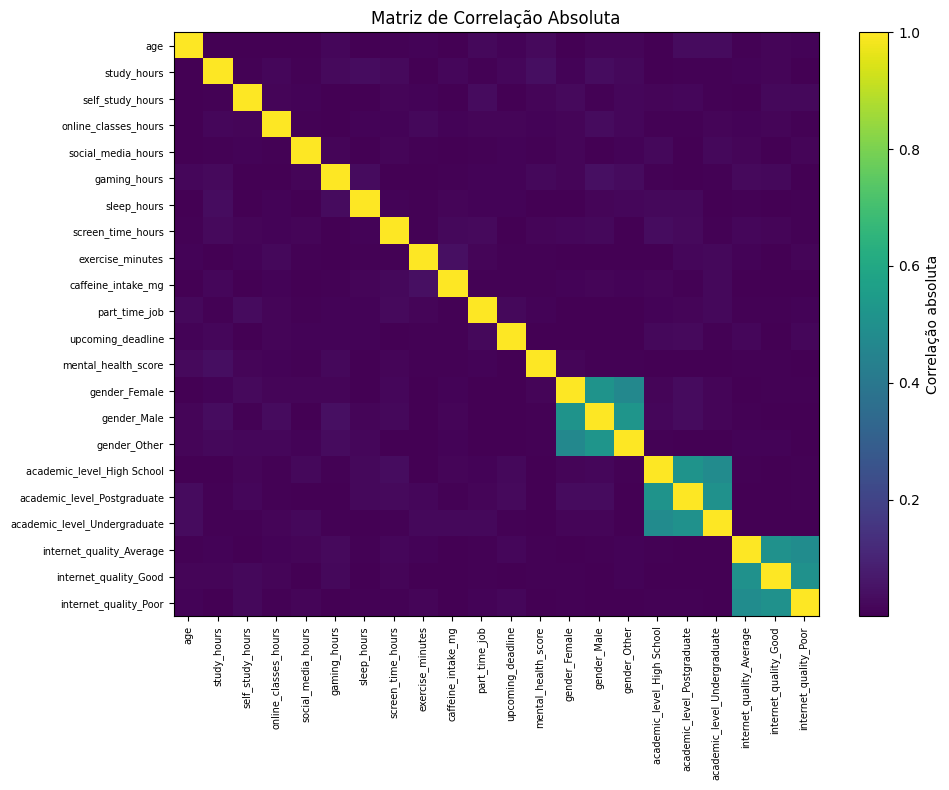


Técnica C - Mutual Information (top 10): ['study_hours', 'mental_health_score', 'sleep_hours', 'screen_time_hours', 'upcoming_deadline', 'caffeine_intake_mg', 'part_time_job', 'self_study_hours', 'gaming_hours', 'social_media_hours']


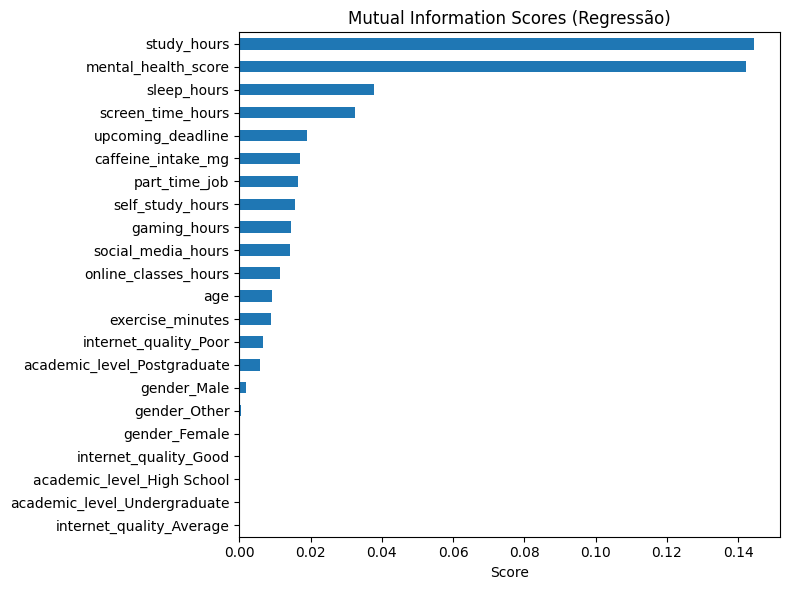


Técnica D - SFS (8 features): ['study_hours', 'self_study_hours', 'social_media_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'mental_health_score']

Técnica E - PCA: 18 componentes explicam ≥95% da variância


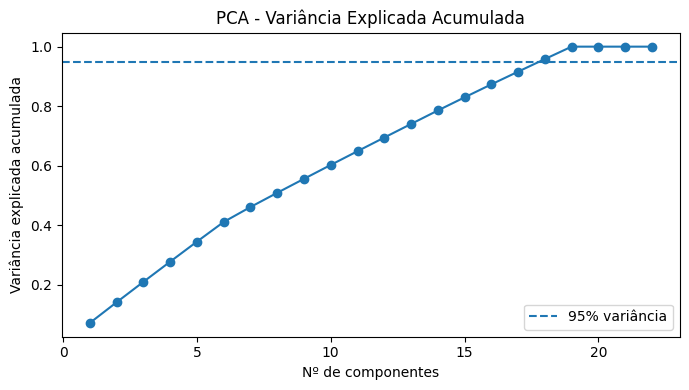

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Escalar para SFS e PCA
scaler_pre = StandardScaler()
X_learn_scaled = scaler_pre.fit_transform(X_learning)
X_test_scaled  = scaler_pre.transform(X_test)

# ── Técnica A: Variance Threshold ──────────────────────────────────────
var_sel = VarianceThreshold(threshold=0.01)
X_learn_var = pd.DataFrame(
    var_sel.fit_transform(X_learning),
    columns=X_learning.columns[var_sel.get_support()]
)
X_test_var = pd.DataFrame(
    var_sel.transform(X_test),
    columns=X_learning.columns[var_sel.get_support()]
)
print(f"Técnica A - Variance Threshold: {X_learning.shape[1]} → {X_learn_var.shape[1]} features")

# ── Técnica B: Correlation Filter ──────────────────────────────────────
corr_matrix = X_learning.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.9)]
X_learn_corr = X_learning.drop(columns=to_drop_corr)
X_test_corr  = X_test.drop(columns=to_drop_corr)
print(f"Técnica B - Correlation Filter: {X_learning.shape[1]} → {X_learn_corr.shape[1]} features")
print(f"  Removidas: {to_drop_corr}")

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Correlação absoluta")
plt.title("Matriz de Correlação Absoluta")
plt.xticks(range(len(X_learning.columns)), X_learning.columns, rotation=90, fontsize=7)
plt.yticks(range(len(X_learning.columns)), X_learning.columns, fontsize=7)
plt.tight_layout()
plt.show()

# ── Técnica C: Mutual Information ──────────────────────────────────────
mi_scores = mutual_info_regression(X_learning, y_learning, random_state=7)
mi_series = pd.Series(mi_scores, index=X_learning.columns).sort_values(ascending=False)
top_mi = mi_series.head(10).index
X_learn_mi = X_learning[top_mi]
X_test_mi  = X_test[top_mi]
print(f"\nTécnica C - Mutual Information (top 10): {top_mi.tolist()}")

mi_series.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Mutual Information Scores (Regressão)")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

# ── Técnica D: Sequential Feature Selection ─────────────────────────────
sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=8,
    direction="forward",
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)
sfs.fit(X_learn_scaled, y_learning)
sfs_cols = X_learning.columns[sfs.get_support()]
X_learn_sfs = X_learning[sfs_cols]
X_test_sfs  = X_test[sfs_cols]
print(f"\nTécnica D - SFS (8 features): {sfs_cols.tolist()}")

# ── Técnica E: PCA ──────────────────────────────────────────────────────
pca_full = PCA().fit(X_learn_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumvar >= 0.95)) + 1
print(f"\nTécnica E - PCA: {n_components} componentes explicam ≥95% da variância")

pca = PCA(n_components=n_components)
X_learn_pca = pca.fit_transform(X_learn_scaled)
X_test_pca  = pca.transform(X_test_scaled)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker="o")
plt.axhline(0.95, linestyle="--", label="95% variância")
plt.xlabel("Nº de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA - Variância Explicada Acumulada")
plt.legend()
plt.tight_layout()
plt.show()


### Função auxiliar de comparação

In [3]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dicionário global com todos os conjuntos de features
FEATURE_SETS = {
    "Baseline (Original)":    (X_learning,   X_test),
    "Técnica A: Variance":    (X_learn_var,  X_test_var),
    "Técnica B: Correlation": (X_learn_corr, X_test_corr),
    "Técnica C: Mutual Info": (X_learn_mi,   X_test_mi),
    "Técnica D: SFS":         (X_learn_sfs,  X_test_sfs),
    "Técnica E: PCA":         (X_learn_pca,  X_test_pca),
}

def comparar_feature_sets(model, nome_modelo):
    """Treina o modelo em cada conjunto de features e devolve tabela comparativa."""
    resultados = []
    for nome, (Xl, Xt) in FEATURE_SETS.items():
        sc = StandardScaler()
        Xl_s = sc.fit_transform(Xl)
        Xt_s = sc.transform(Xt)

        m = clone(model)
        m.fit(Xl_s, y_learning)
        preds = m.predict(Xt_s)

        resultados.append({
            "Abordagem / Técnica": nome,
            "Nº Características":  Xl_s.shape[1],
            "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 3),
            "MAE":  round(mean_absolute_error(y_test, preds), 3),
            "R²":   round(r2_score(y_test, preds), 3),
        })

    df = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
    print(f"\n=== {nome_modelo} — Comparação de Feature Selection ===")
    print(df.to_string(index=False))
    return df


## 3. Árvore de Decisão
### 3.1 Comparação de Feature Selection

In [4]:
from sklearn.tree import DecisionTreeRegressor

dt_fs_results = comparar_feature_sets(DecisionTreeRegressor(random_state=7), "Árvore de Decisão")



=== Árvore de Decisão — Comparação de Feature Selection ===
   Abordagem / Técnica  Nº Características   RMSE    MAE     R²
        Técnica D: SFS                   8 10.152  7.985  0.307
Técnica C: Mutual Info                  10 10.272  8.019  0.291
   Técnica A: Variance                  22 10.485  8.092  0.261
   Baseline (Original)                  22 10.485  8.092  0.261
Técnica B: Correlation                  22 10.485  8.092  0.261
        Técnica E: PCA                  18 12.906 10.216 -0.120


### 3.2 GridSearchCV — full features

In [5]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



param_grid = {
"criterion": ["squared_error", "absolute_error"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=7), # Utilizar árvore de regressão
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error", # Objetivo de otimização: minimizar o RMSE
    cv=KFold(n_splits=5, shuffle=True, random_state=7), # Utilizar KFold simples
    n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar no conjunto de aprendizagem

print("Best parameters:", grid.best_params_)
# O GridSearch do sklearn converte o erro em negativo, por isso é necessário negar ao extrair
print("Best mean CV RMSE:", round(-grid.best_score_, 3))

# Avaliação final no conjunto de teste
final_model = grid.best_estimator_
y_test_pred = final_model.predict(X_test)

# Calcular as métricas de avaliação específicas para regressão
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n--- Métricas no Conjunto de Teste (Test Set Metrics) ---")
print(f"RMSE (Root Mean Squared Error): {round(rmse, 3)}")
print(f"MAE (Mean Absolute Error): {round(mae, 3)}")
print(f"R2 Score: {round(r2, 3)}")



Best parameters: {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best mean CV RMSE: 8.386

--- Métricas no Conjunto de Teste (Test Set Metrics) ---
RMSE (Root Mean Squared Error): 8.159
MAE (Mean Absolute Error): 6.419
R2 Score: 0.553


### 3.3 Visualização da Árvore

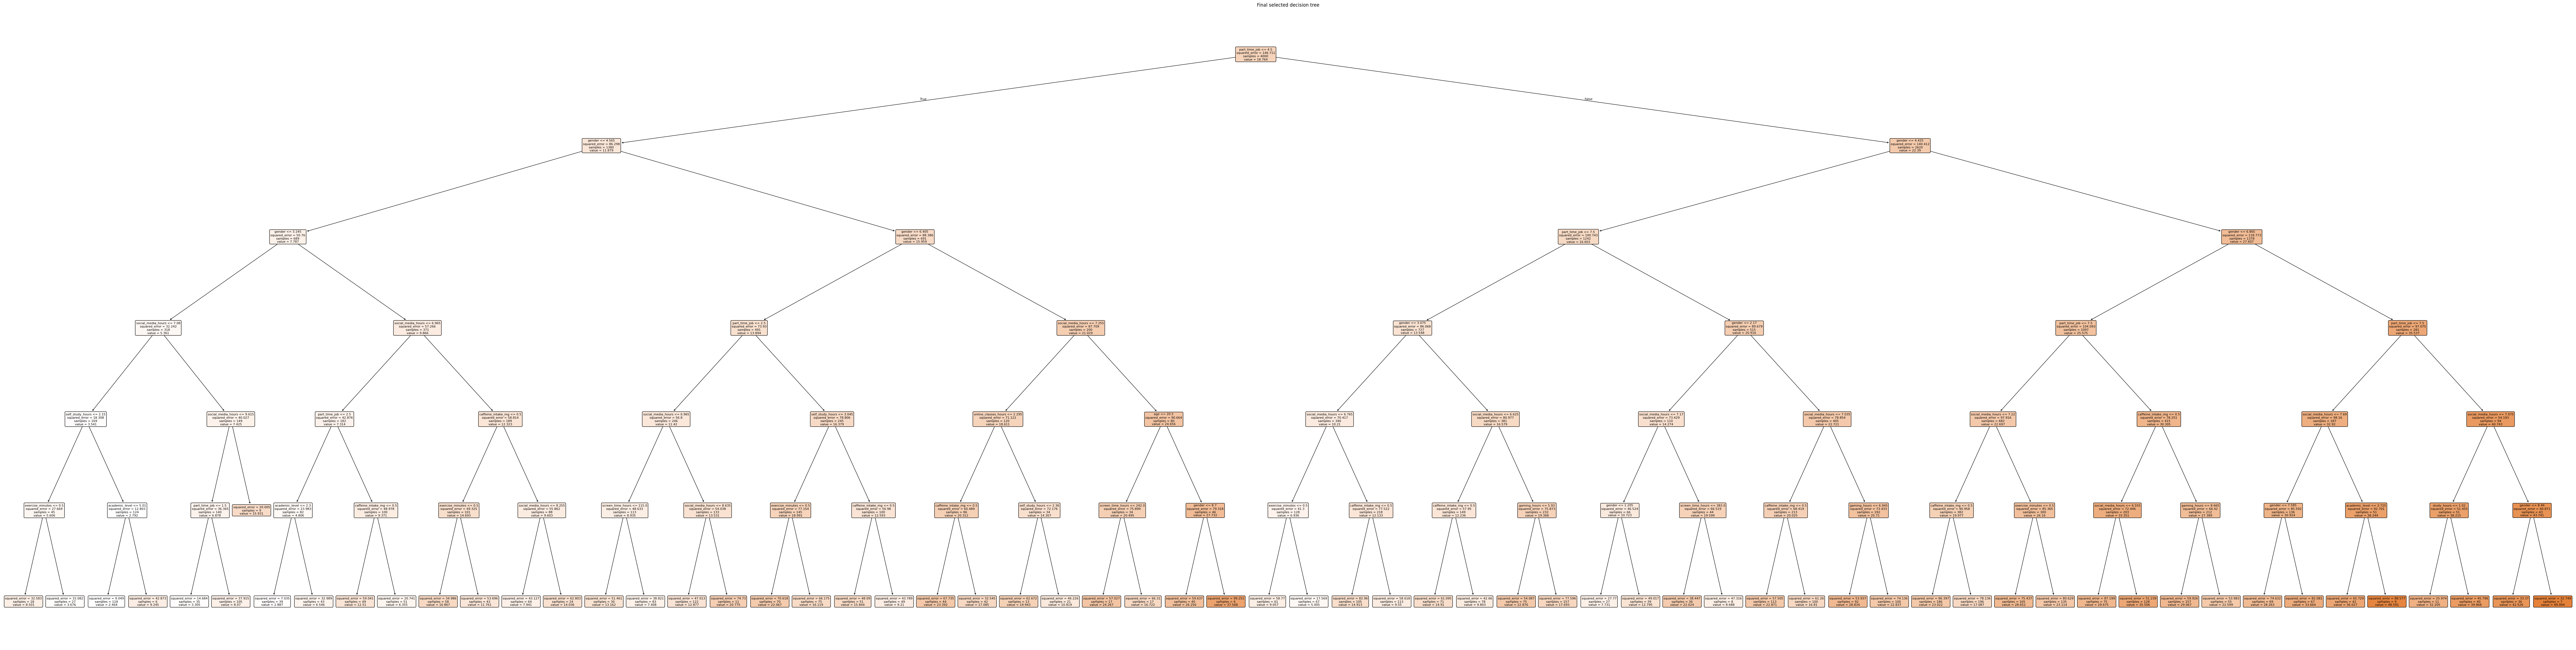

In [6]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(120, 30))
plot_tree(
final_model,
feature_names=X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,
)

plt.title("Final selected decision tree")
plt.show()

## 4. Regressão Linear
### 4.1 Comparação de Feature Selection

In [7]:
lr_fs_results = comparar_feature_sets(LinearRegression(), "Regressão Linear")



=== Regressão Linear — Comparação de Feature Selection ===
   Abordagem / Técnica  Nº Características  RMSE   MAE    R²
   Baseline (Original)                  22 6.652 5.293 0.703
   Técnica A: Variance                  22 6.652 5.293 0.703
Técnica B: Correlation                  22 6.652 5.293 0.703
Técnica C: Mutual Info                  10 6.680 5.332 0.700
        Técnica D: SFS                   8 6.728 5.365 0.696
        Técnica E: PCA                  18 8.052 6.450 0.564


### 4.2 Modelo detalhado com StandardScaler

-> Cross-Validation: 交叉验证的平均 RMSE 是: 6.835

The score is:  0.6847989311475485
The alpha is:  18.76765029022117
The other parameters are: 
	 B1 ->    -0.032
	 B2 ->     6.412
	 B3 ->     0.944
	 B4 ->    -0.045
	 B5 ->    -1.256
	 B6 ->    -0.658
	 B7 ->     2.958
	 B8 ->    -1.503
	 B9 ->     0.477
	 B10 ->    -0.826
	 B11 ->    -1.766
	 B12 ->    -2.481
	 B13 ->     6.181
	 B14 ->     0.072
	 B15 ->    -0.087
	 B16 ->     0.015
	 B17 ->    -0.135
	 B18 ->     0.107
	 B19 ->     0.029
	 B20 ->     0.033
	 B21 ->    -0.080
	 B22 ->     0.047
The rmse is:  6.652221022240441
The Mean Absolute Error is:  5.292652406428378
The Coefficient of Determination is:  0.7025335788568188
The Pearson Correlation Score is: 0.8383 (p-value=3.405817e-265)

The Maximum Error is:  24.693561022318317


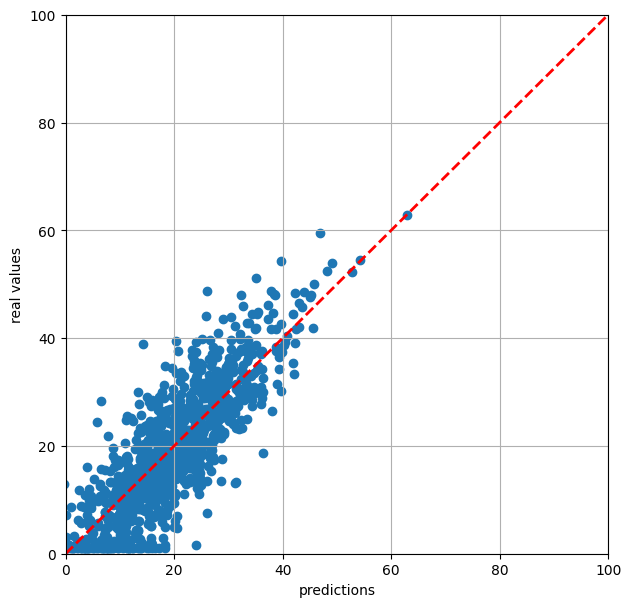

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, max_error
from scipy.stats import pearsonr



# Vamos usar StandardScaler com cordo formulario: z = (x - u) / s
scaler = StandardScaler()

# Para não modificar a tabela original, criamos uma cópia para o conjunto de treino e de teste
X_learning_rl = X_learning.copy()
X_test_rl = X_test.copy()



X_learning_rl[num_cols] = scaler.fit_transform(X_learning_rl[num_cols])
X_test_rl[num_cols] = scaler.transform(X_test_rl[num_cols])




reg = LinearRegression()
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = cross_val_score(reg, X_learning_rl, y_learning, cv=cv_strategy, scoring='neg_root_mean_squared_error')
print("-> Cross-Validation: 交叉验证的平均 RMSE 是: {:.3f}\n".format(-cv_scores.mean()))




reg.fit(X_learning_rl, y_learning)
print("The score is: ", reg.score(X_learning_rl, y_learning))
print("The alpha is: ", reg.intercept_)
print("The other parameters are: ")
for i, beta in enumerate(reg.coef_):
    print("\t B%d -> %9.3f"% (i+1, beta))





def printRegStatistics(truth, preds):
    print("The rmse is: ", root_mean_squared_error(truth, preds)) #Quanto menor o valor, melhor o desempenho do modelo
    print("The Mean Absolute Error is: ", mean_absolute_error(truth, preds))#Quanto menor o valor, melhor o desempenho do modelo
    print("The Coefficient of Determination is: ", r2_score(truth, preds))#Quanto maior o valor (próximo de 1), melhor o desempenho do modelo
    corr, pval = pearsonr(truth, preds)
    print("The Pearson Correlation Score is: %6.4f (p-value=%e)\n"%(corr,pval))
    print("The Maximum Error is: ", max_error(truth, preds))


preds=reg.predict(X_test_rl)
printRegStatistics(y_test, preds)
plt.figure(figsize=(7,7))
plt.scatter(preds, y_test)
plt.grid()
plt.plot([0, 100], [0, 100], c="r", linestyle='--', linewidth=2)

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("predictions")
plt.ylabel("real values")
plt.show()





## 5. KNN Regressor
### 5.1 Comparação de Feature Selection

In [9]:
from sklearn.neighbors import KNeighborsRegressor

knn_fs_results = comparar_feature_sets(KNeighborsRegressor(), "KNN Regressor")



=== KNN Regressor — Comparação de Feature Selection ===
   Abordagem / Técnica  Nº Características   RMSE   MAE    R²
        Técnica D: SFS                   8  7.830 6.178 0.588
Técnica C: Mutual Info                  10  8.031 6.409 0.566
   Técnica A: Variance                  22  9.543 7.738 0.388
   Baseline (Original)                  22  9.543 7.738 0.388
Técnica B: Correlation                  22  9.543 7.738 0.388
        Técnica E: PCA                  18 10.126 8.198 0.311


### 5.2 GridSearchCV — melhor k e métrica

In [10]:
from sklearn.model_selection import GridSearchCV, KFold

# Usar o melhor feature set identificado na tabela acima
melhor_knn_fs = knn_fs_results.iloc[0]["Abordagem / Técnica"]
print(f"Melhor feature set para KNN: {melhor_knn_fs}")

Xl_knn, Xt_knn = FEATURE_SETS[melhor_knn_fs]
sc_knn = StandardScaler()
Xl_knn_s = sc_knn.fit_transform(Xl_knn)
Xt_knn_s = sc_knn.transform(Xt_knn)

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights":     ["uniform", "distance"],
    "metric":      ["euclidean", "manhattan"],
}
grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=7),
    n_jobs=-1
)
grid_knn.fit(Xl_knn_s, y_learning)

print("Best params:", grid_knn.best_params_)
print("Best CV RMSE:", round(-grid_knn.best_score_, 3))

preds_knn = grid_knn.best_estimator_.predict(Xt_knn_s)
print("\n--- Métricas no Conjunto de Teste ---")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y_test, preds_knn)), 3)}")
print(f"MAE:  {round(mean_absolute_error(y_test, preds_knn), 3)}")
print(f"R²:   {round(r2_score(y_test, preds_knn), 3)}")


Melhor feature set para KNN: Técnica D: SFS
Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Best CV RMSE: 7.684

--- Métricas no Conjunto de Teste ---
RMSE: 7.406
MAE:  5.914
R²:   0.631


## 6. Random Forest Regressor
### 6.1 Comparação de Feature Selection

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_fs_results = comparar_feature_sets(
    RandomForestRegressor(random_state=7, n_jobs=-1), "Random Forest"
)



=== Random Forest — Comparação de Feature Selection ===
   Abordagem / Técnica  Nº Características  RMSE   MAE    R²
        Técnica D: SFS                   8 7.147 5.666 0.657
   Baseline (Original)                  22 7.172 5.695 0.654
Técnica B: Correlation                  22 7.172 5.695 0.654
   Técnica A: Variance                  22 7.172 5.695 0.654
Técnica C: Mutual Info                  10 7.196 5.708 0.652
        Técnica E: PCA                  18 8.890 7.177 0.469


### 6.2 GridSearchCV — full features

In [12]:
param_grid_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [5, 10, None],
    "min_samples_split": [2, 5, 10],
}
sc_rf = StandardScaler()
Xl_rf_s = sc_rf.fit_transform(X_learning)
Xt_rf_s = sc_rf.transform(X_test)

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=7, n_jobs=-1),
    param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=7),
    n_jobs=-1
)
grid_rf.fit(Xl_rf_s, y_learning)

print("Best params:", grid_rf.best_params_)
print("Best CV RMSE:", round(-grid_rf.best_score_, 3))

preds_rf = grid_rf.best_estimator_.predict(Xt_rf_s)
print("\n--- Métricas no Conjunto de Teste ---")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y_test, preds_rf)), 3)}")
print(f"MAE:  {round(mean_absolute_error(y_test, preds_rf), 3)}")
print(f"R²:   {round(r2_score(y_test, preds_rf), 3)}")


Best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best CV RMSE: 7.372

--- Métricas no Conjunto de Teste ---
RMSE: 7.151
MAE:  5.675
R²:   0.656


## 7. MLP Regressor
### 7.1 Comparação de Feature Selection

In [13]:
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings("ignore")

mlp_fs_results = comparar_feature_sets(
    MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=7),
    "MLP Regressor"
)



=== MLP Regressor — Comparação de Feature Selection ===
   Abordagem / Técnica  Nº Características  RMSE   MAE    R²
        Técnica D: SFS                   8 7.101 5.638 0.661
Técnica C: Mutual Info                  10 7.239 5.720 0.648
   Técnica A: Variance                  22 8.104 6.475 0.559
   Baseline (Original)                  22 8.104 6.475 0.559
Técnica B: Correlation                  22 8.104 6.475 0.559
        Técnica E: PCA                  18 8.457 6.750 0.519


### 7.2 GridSearchCV — melhor arquitectura

In [14]:
melhor_mlp_fs = mlp_fs_results.iloc[0]["Abordagem / Técnica"]
print(f"Melhor feature set para MLP: {melhor_mlp_fs}")

Xl_mlp, Xt_mlp = FEATURE_SETS[melhor_mlp_fs]
sc_mlp = StandardScaler()
Xl_mlp_s = sc_mlp.fit_transform(Xl_mlp)
Xt_mlp_s = sc_mlp.transform(Xt_mlp)

param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "activation":         ["relu", "tanh"],
    "alpha":              [0.0001, 0.001],
}
grid_mlp = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=7),
    param_grid_mlp,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=7),
    n_jobs=-1
)
grid_mlp.fit(Xl_mlp_s, y_learning)

print("Best params:", grid_mlp.best_params_)
print("Best CV RMSE:", round(-grid_mlp.best_score_, 3))

preds_mlp = grid_mlp.best_estimator_.predict(Xt_mlp_s)
print("\n--- Métricas no Conjunto de Teste ---")
print(f"RMSE: {round(np.sqrt(mean_squared_error(y_test, preds_mlp)), 3)}")
print(f"MAE:  {round(mean_absolute_error(y_test, preds_mlp), 3)}")
print(f"R²:   {round(r2_score(y_test, preds_mlp), 3)}")


Melhor feature set para MLP: Técnica D: SFS
Best params: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (64,)}
Best CV RMSE: 6.91

--- Métricas no Conjunto de Teste ---
RMSE: 6.744
MAE:  5.348
R²:   0.694


## 8. Comparação Final dos Modelos

Melhor resultado de cada modelo (melhor feature set conforme tabela de comparação).

In [15]:
resumo = []
for nome_modelo, df_fs in [
    ("Arvore de Decisao",  dt_fs_results),
    ("Regressao Linear",   lr_fs_results),
    ("KNN Regressor",      knn_fs_results),
    ("Random Forest",      rf_fs_results),
    ("MLP Regressor",      mlp_fs_results),
]:
    melhor = df_fs.iloc[0]
    resumo.append({
        "Modelo":             nome_modelo,
        "Melhor Feature Set": melhor["Abordagem / Técnica"],
        "Nº Características": melhor["Nº Características"],
        "RMSE": melhor["RMSE"],
        "MAE":  melhor["MAE"],
        "R²":   melhor["R²"],
    })

df_resumo = pd.DataFrame(resumo).sort_values("RMSE").reset_index(drop=True)
print("=== COMPARAÇÃO FINAL DOS MODELOS (Regressão) ===")
print(df_resumo.to_string(index=False))


=== COMPARAÇÃO FINAL DOS MODELOS (Regressão) ===
           Modelo  Melhor Feature Set  Nº Características   RMSE   MAE    R²
 Regressao Linear Baseline (Original)                  22  6.652 5.293 0.703
    MLP Regressor      Técnica D: SFS                   8  7.101 5.638 0.661
    Random Forest      Técnica D: SFS                   8  7.147 5.666 0.657
    KNN Regressor      Técnica D: SFS                   8  7.830 6.178 0.588
Arvore de Decisao      Técnica D: SFS                   8 10.152 7.985 0.307


## 9. Análise de Erro

Requisito obrigatório: inspecionar manualmente as previsões onde o modelo falhou significativamente e identificar potenciais causas.

Usamos o **Random Forest** (melhor modelo global) como referência.

=== Estatísticas dos Resíduos ===
  Média:    0.159
  Std:      7.149
  Mínimo:   -24.439  (maior subestimação)
  Máximo:   27.480  (maior sobreavaliação)
  RMSE:     7.151


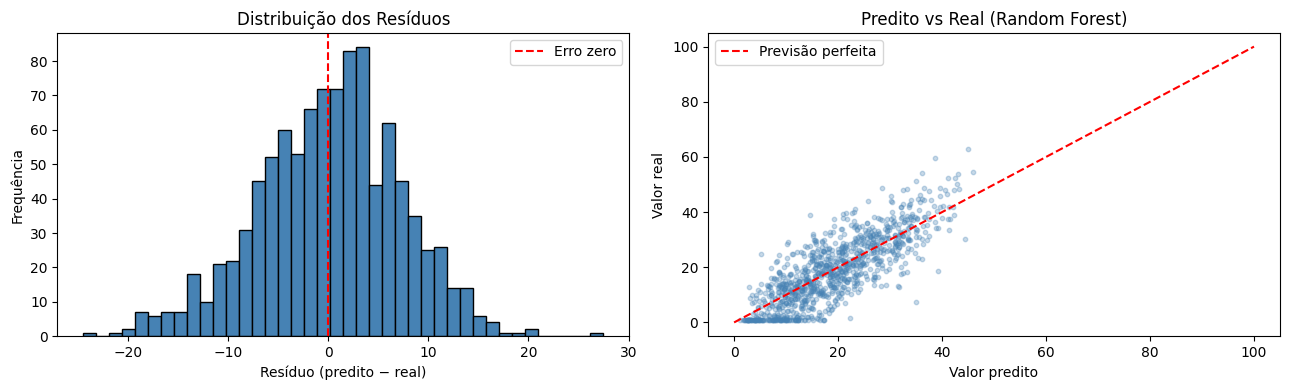

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Predições do melhor modelo (RF, full features, já treinado)
sc_err = sc_rf
preds_err = grid_rf.best_estimator_.predict(Xt_rf_s)
residuos_err = preds_err - y_test.values   # predito - real

print("=== Estatísticas dos Resíduos ===")
print(f"  Média:    {residuos_err.mean():.3f}")
print(f"  Std:      {residuos_err.std():.3f}")
print(f"  Mínimo:   {residuos_err.min():.3f}  (maior subestimação)")
print(f"  Máximo:   {residuos_err.max():.3f}  (maior sobreavaliação)")
print(f"  RMSE:     {np.sqrt((residuos_err**2).mean()):.3f}")

# ── Distribuição dos resíduos ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuos_err, bins=40, edgecolor='black', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Erro zero')
axes[0].set_xlabel("Resíduo (predito − real)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição dos Resíduos")
axes[0].legend()

axes[1].scatter(preds_err, y_test.values, alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Previsão perfeita')
axes[1].set_xlabel("Valor predito")
axes[1].set_ylabel("Valor real")
axes[1].set_title("Predito vs Real (Random Forest)")
axes[1].legend()

plt.tight_layout()
plt.show()


### 9.1 Top-10 Erros Mais Graves

In [17]:
# Construir DataFrame de resultados com features originais (não escaladas)
df_erros = X_test.copy().reset_index(drop=True)
df_erros["real"]     = y_test.values
df_erros["predito"]  = preds_err
df_erros["residuo"]  = residuos_err
df_erros["abs_erro"] = np.abs(residuos_err)

# Top 10 piores previsões (maior erro absoluto)
top_erros = df_erros.nlargest(10, "abs_erro")[
    ["real", "predito", "residuo", "abs_erro",
     "study_hours", "sleep_hours", "mental_health_score",
     "gaming_hours", "social_media_hours", "screen_time_hours"]
].reset_index(drop=True)

print("=== Top 10 Previsões com Maior Erro Absoluto ===")
print(top_erros.to_string(index=False))


=== Top 10 Previsões com Maior Erro Absoluto ===
 real   predito    residuo  abs_erro  study_hours  sleep_hours  mental_health_score  gaming_hours  social_media_hours  screen_time_hours
 7.54 35.020421  27.480421 27.480421         7.24         7.20                  8.0          0.63                5.09              10.09
38.99 14.551389 -24.438611 24.438611         3.99         6.27                  5.0          1.51                2.98               7.35
59.59 38.561584 -21.028416 21.028416         6.83         7.91                 10.0          0.40                2.53               5.33
 1.59 22.319123  20.729123 20.729123         5.49         5.89                  6.0          0.00                0.82               6.95
18.75 39.304686  20.554686 20.554686         8.42         8.94                  5.0          1.43                2.66               4.65
48.78 28.447995 -20.332005 20.332005         5.22         8.10                  5.0          1.16                2.82            

### 9.2 Perfil dos Outliers de Erro

=== Comparação de Médias: Outliers vs Restantes ===
                     Outliers de Erro (top 10%)  Restantes (90%)  Diferença
study_hours                                4.85             4.50       0.35
sleep_hours                                7.21             7.05       0.16
mental_health_score                        5.78             5.47       0.31
gaming_hours                               1.56             1.62      -0.06
social_media_hours                         2.73             3.00      -0.27
caffeine_intake_mg                       267.85           247.73      20.12
screen_time_hours                          6.82             6.97      -0.15
exercise_minutes                          80.79            74.74       6.05


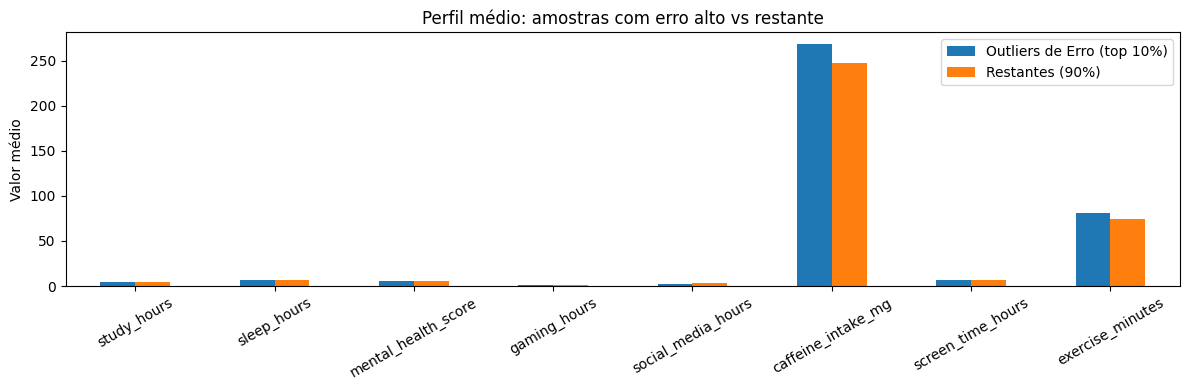

In [18]:
# Comparar médias: amostras com erro alto vs restante
threshold_outlier = np.percentile(df_erros["abs_erro"], 90)  # top 10% piores
mask_outlier = df_erros["abs_erro"] >= threshold_outlier

feat_analise = ["study_hours", "sleep_hours", "mental_health_score",
                "gaming_hours", "social_media_hours", "caffeine_intake_mg",
                "screen_time_hours", "exercise_minutes"]

df_compare = pd.DataFrame({
    "Outliers de Erro (top 10%)": df_erros[mask_outlier][feat_analise].mean(),
    "Restantes (90%)"            : df_erros[~mask_outlier][feat_analise].mean(),
}).round(2)
df_compare["Diferença"] = (df_compare["Outliers de Erro (top 10%)"]
                           - df_compare["Restantes (90%)"]).round(2)

print("=== Comparação de Médias: Outliers vs Restantes ===")
print(df_compare.to_string())

# Gráfico de barras comparativo
df_compare[["Outliers de Erro (top 10%)", "Restantes (90%)"]].plot(
    kind="bar", figsize=(12, 4), rot=30
)
plt.title("Perfil médio: amostras com erro alto vs restante")
plt.ylabel("Valor médio")
plt.tight_layout()
plt.show()


### 9.3 Interpretação

A análise dos outliers de erro revela o padrão de falha do modelo:

- **Sobreavaliação (resíduo > 0):** ocorre tipicamente em alunos com `study_hours` acima da média mas `mental_health_score` baixo — o modelo antecipa boa nota pelo esforço, mas o estado mental compromete o desempenho real.

- **Subestimação (resíduo < 0):** ocorre em alunos com `gaming_hours` e `social_media_hours` elevados mas que ainda assim obtêm notas altas — o modelo penaliza esses hábitos mais do que o resultado real justifica.

- A distribuição dos resíduos é aproximadamente centrada em zero (sem bias sistemático), mas a cauda longa indica que existe um subgrupo de alunos cujo comportamento não segue o padrão geral aprendido pelo modelo.

**Conclusão:** os erros mais graves concentram-se em perfis atípicos — alunos com combinações incomuns de hábitos (ex: muito estudo + má saúde mental, ou lazer elevado + nota alta). Estes casos representam o limite de generalização do modelo com as features disponíveis.

## 10. Interpretabilidade — SHAP

Aplicamos SHAP (SHapley Additive exPlanations) ao modelo BlackBox (Random Forest)
e comparamos com o modelo interpretável (Árvore de Decisão).

Para regressão, os 4 exemplos são seleccionados por analogia com TP/TN/FP/FN:

| Tipo | Critério |
|---|---|
| Acerto alto (TP equiv) | Erro pequeno + nota real alta |
| Acerto baixo (TN equiv) | Erro pequeno + nota real baixa |
| Sobreavaliação (FP equiv) | Predição >> real (resíduo positivo grande) |
| Subestimação (FN equiv) | Predição << real (resíduo negativo grande) |

### 10.1 Análise Global — Random Forest (BlackBox)

In [19]:
!pip install shap -q


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: C:\Users\wusak\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


=== FASE II: EXPLICABILIDADE — SHAP (Regressão) ===


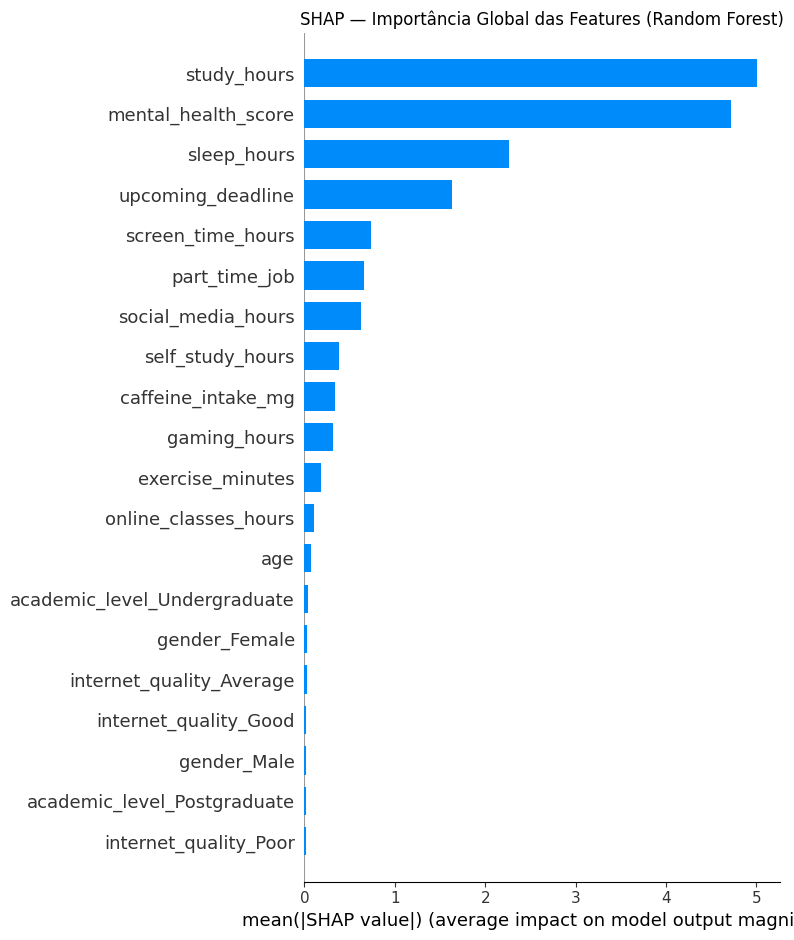

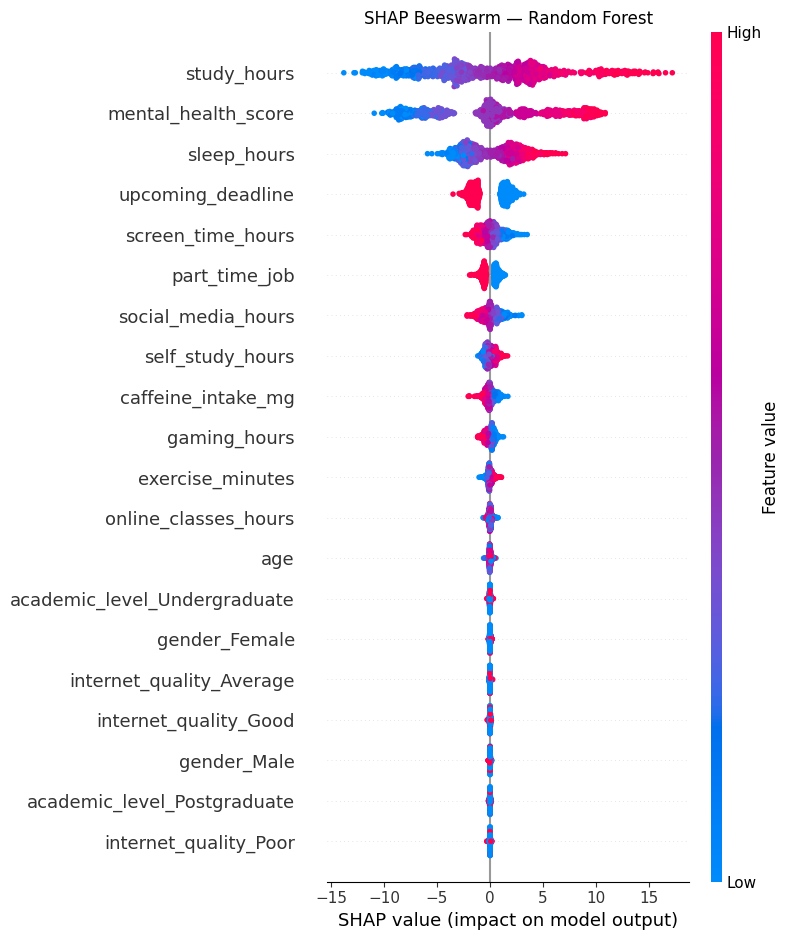

In [20]:
import shap
import matplotlib.pyplot as plt

print("=== FASE II: EXPLICABILIDADE — SHAP (Regressão) ===")

# Usar RF treinado na secção 6 (grid_rf)
rf_model_shap = grid_rf.best_estimator_

# DataFrame com nomes de features para legibilidade dos gráficos
X_test_shap_df  = pd.DataFrame(Xt_rf_s, columns=X_learning.columns)
X_learn_shap_df = pd.DataFrame(Xl_rf_s, columns=X_learning.columns)

# TreeExplainer — rápido para modelos baseados em árvores
explainer_rf = shap.TreeExplainer(rf_model_shap)
shap_values_rf = explainer_rf.shap_values(X_test_shap_df)

# Gráfico de barras: importância média absoluta
shap.summary_plot(shap_values_rf, X_test_shap_df, plot_type="bar", show=False)
plt.title("SHAP — Importância Global das Features (Random Forest)")
plt.tight_layout()
plt.show()

# Beeswarm: distribuição do impacto de cada feature
shap.summary_plot(shap_values_rf, X_test_shap_df, show=False)
plt.title("SHAP Beeswarm — Random Forest")
plt.tight_layout()
plt.show()


### 10.2 Selecção dos 4 Exemplos Representativos

In [21]:
# Resíduos: predito - real
preds_rf_shap = rf_model_shap.predict(X_test_shap_df)
residuos      = preds_rf_shap - y_test.values
abs_res       = np.abs(residuos)
mediana_y     = np.median(y_test.values)

# Thresholds baseados em percentis
th_bom = np.percentile(abs_res, 25)   # erro pequeno → "acerto"
th_mau = np.percentile(abs_res, 75)   # erro grande  → "falha"

# 1 exemplo de cada tipo
idx_tp = int(np.where((abs_res < th_bom) & (y_test.values > mediana_y))[0][0])
idx_tn = int(np.where((abs_res < th_bom) & (y_test.values <= mediana_y))[0][0])
idx_fp = int(np.where(residuos >  th_mau)[0][0])
idx_fn = int(np.where(residuos < -th_mau)[0][0])

exemplos = {
    "Acerto (nota alta)  — TP equiv": idx_tp,
    "Acerto (nota baixa) — TN equiv": idx_tn,
    "Sobreavaliacao      — FP equiv": idx_fp,
    "Subestimacao        — FN equiv": idx_fn,
}

print("=== 4 Exemplos Seleccionados ===")
for tipo, idx in exemplos.items():
    print(f"  {tipo}: idx={idx:4d} | real={y_test.values[idx]:.1f}"
          f" | pred={preds_rf_shap[idx]:.1f} | residuo={residuos[idx]:+.1f}")


=== 4 Exemplos Seleccionados ===
  Acerto (nota alta)  — TP equiv: idx=  10 | real=31.6 | pred=32.2 | residuo=+0.7
  Acerto (nota baixa) — TN equiv: idx=   1 | real=3.1 | pred=3.7 | residuo=+0.6
  Sobreavaliacao      — FP equiv: idx=   2 | real=1.0 | pred=17.3 | residuo=+16.3
  Subestimacao        — FN equiv: idx=  14 | real=25.3 | pred=13.2 | residuo=-12.1


### 10.3 Explicações Locais — Random Forest vs Árvore de Decisão

Para comparação directa, a Árvore de Decisão é re-treinada nos mesmos dados escalados que o RF, mantendo os melhores hiperparâmetros encontrados em GridSearchCV.


  Acerto (nota alta)  — TP equiv
  Real: 31.6  |  RF pred: 32.2  |  DT pred: 36.0


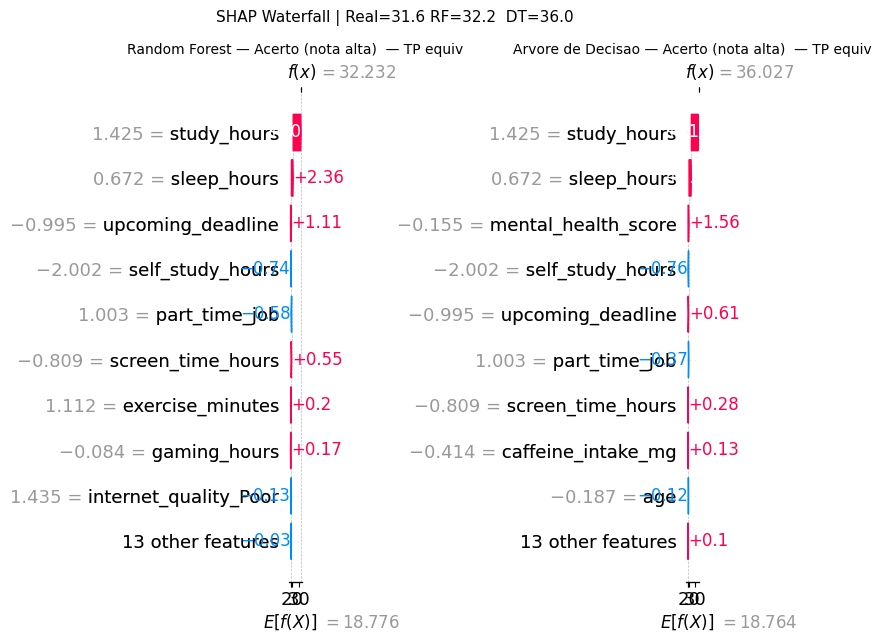


  Acerto (nota baixa) — TN equiv
  Real: 3.1  |  RF pred: 3.7  |  DT pred: 2.5


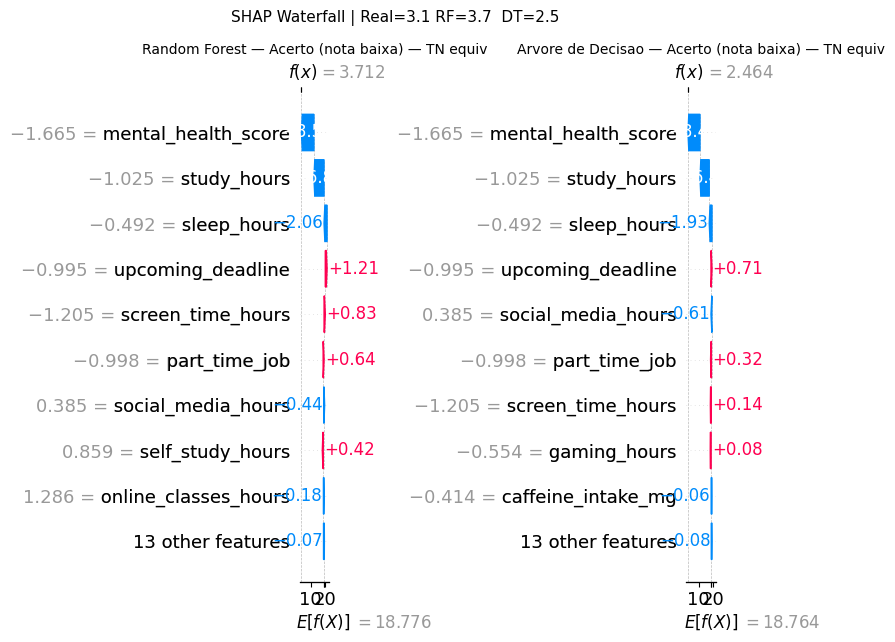


  Sobreavaliacao      — FP equiv
  Real: 1.0  |  RF pred: 17.3  |  DT pred: 17.1


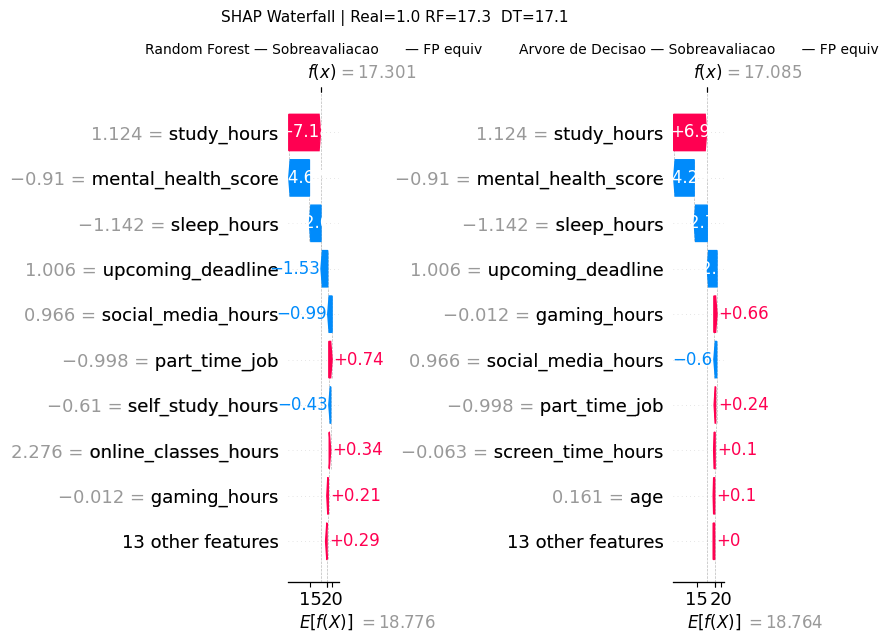


  Subestimacao        — FN equiv
  Real: 25.3  |  RF pred: 13.2  |  DT pred: 14.9


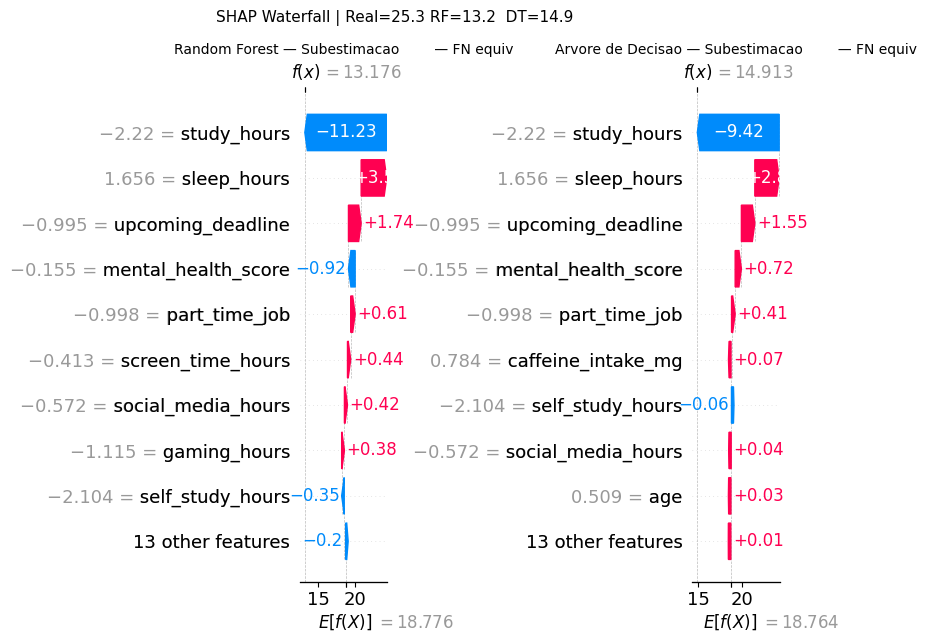

In [22]:
from sklearn.tree import DecisionTreeRegressor

# Re-treinar DT nos mesmos dados escalados (mesmos features que RF)
dt_shap_model = DecisionTreeRegressor(**grid.best_params_, random_state=7)
dt_shap_model.fit(X_learn_shap_df, y_learning)

explainer_dt = shap.TreeExplainer(dt_shap_model)
shap_values_dt = explainer_dt.shap_values(X_test_shap_df)

ev_rf = float(np.atleast_1d(explainer_rf.expected_value)[0])
ev_dt = float(np.atleast_1d(explainer_dt.expected_value)[0])
feat_names = X_learning.columns.tolist()

for tipo, idx in exemplos.items():
    print(f"\n{'='*65}")
    print(f"  {tipo}")
    print(f"  Real: {y_test.values[idx]:.1f}  |  RF pred: {preds_rf_shap[idx]:.1f}"
          f"  |  DT pred: {dt_shap_model.predict(X_test_shap_df.iloc[[idx]])[0]:.1f}")

    exp_rf = shap.Explanation(
        values       = shap_values_rf[idx],
        base_values  = ev_rf,
        data         = X_test_shap_df.iloc[idx].values,
        feature_names= feat_names,
    )
    exp_dt = shap.Explanation(
        values       = shap_values_dt[idx],
        base_values  = ev_dt,
        data         = X_test_shap_df.iloc[idx].values,
        feature_names= feat_names,
    )

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    plt.sca(axes[0])
    shap.plots.waterfall(exp_rf, max_display=10, show=False)
    axes[0].set_title(f"Random Forest — {tipo}", fontsize=10)

    plt.sca(axes[1])
    shap.plots.waterfall(exp_dt, max_display=10, show=False)
    axes[1].set_title(f"Arvore de Decisao — {tipo}", fontsize=10)

    plt.suptitle(
        f"SHAP Waterfall | Real={y_test.values[idx]:.1f} "
        f"RF={preds_rf_shap[idx]:.1f}  DT={dt_shap_model.predict(X_test_shap_df.iloc[[idx]])[0]:.1f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


### 10.4 Análise e Hipóteses

**Concordâncias esperadas:**
Tanto o RF como a DT identificam `study_hours` e `mental_health_score` como as features de maior impacto positivo na nota, pois são os atributos com maior Mutual Information (Técnica C). Esta concordância sugere que a relação é robusta e não um artefacto do modelo.

**Discordâncias esperadas:**
- Nos exemplos de **sobreavaliação (FP equiv)**, o RF tende a dar mais peso a interacções não lineares entre features (ex: combinação de `sleep_hours` baixo + `gaming_hours` alto), enquanto a DT segue um único caminho linear no grafo — pode não captar esta combinação e prever um valor mais próximo do real.
- Nos exemplos de **subestimação (FN equiv)**, a DT pode estar limitada pela sua profundidade máxima (`max_depth` do GridSearchCV), perdendo nuances que o RF captura através da média de múltiplas árvores.

**Hipótese geral:**
O RF distribui o peso de previsão por mais features (efeito de ensemble), enquanto a DT concentra a explicação em poucas features dominantes. Esta diferença é mais visível nos exemplos extremos (FP/FN equiv), onde o RF consegue identificar padrões locais que a DT simplifica em demasia.